# Project Title: Vocal Isolation for Music (Source Separation)

**Student Name:** Ahmad Hasan

**Registration Number:** 40294488

**Introduction:**

This notebook details the implementation and evaluation of a deep learning model for vocal isolation (source separation) in music. The primary objective of this project was to develop a model capable of effectively separating vocal tracks from their accompanying instrumental music using publicly available datasets. This task holds significant importance and finds applications in various fields such as music remixing, karaoke system development, music analysis, and audio restoration.

The project commenced with a thorough literature review to understand existing approaches for vocal isolation. Following this, the MUSDB18 dataset was downloaded. This dataset, encoded in the STEMS format (a multitrack audio format utilizing lossy compression within .mp4 containers), presented an initial challenge in terms of decoding. While an initial attempt was made using the base `ffmpeg` library for stem extraction, a review of relevant literature highlighted the `musdb` package as a more streamlined solution for handling this specific dataset format. The `musdb` package, leveraging FFMPEG internally, simplified the process of understanding and accessing the individual audio streams.

Subsequently, to gain inspiration and establish a foundational approach, various open-source recipes provided by SpeechBrain were explored. The "Speech separation with LibriMix" recipe, in particular, exhibited significant similarities to the task at hand and was closely studied. This recipe served as a crucial guideline for the project. However, adapting this recipe to the MUSDB18 dataset proved to be a substantial challenge due to the inherent differences in dataset formats. Consequently, a significant effort was dedicated to rewriting the entire training pipeline to ensure compatibility and effective processing of the MUSDB18 data.


---


####**Note**:This notebook showcases the final and most enhanced version of the vocal isolation experiment conducted during this project. Earlier experiments, along with detailed evaluations, challenges, and iterative improvements, are thoroughly documented in the attached project report.



---
**Please note** that all directories in this notebook are currently configured for the directory structure used in Paperspace notebooks. If you're running this notebook in a different IDE or environment, you may need to adjust the paths accordingly.


# 1. Data Preparation

This section outlines the initial steps taken to interact with the MUSDB18 dataset. It covers the installation of necessary libraries and a preliminary exploration of the dataset structure through audio sample playback.

## 1.1 Installing Dependencies

The following cell installs the required libraries for working with the MUSDB18 dataset and handling audio files. Specifically:

-   `musdb`: This Python package provides convenient tools for accessing and working with the MUSDB18 dataset.

-   `numpy==1.23.5`: This specific version of the NumPy library is installed to ensure compatibility and avoid potential errors related to the removal of `np.float_` in later NumPy versions.


In [1]:
!pip install musdb
!pip install numpy==1.23.5

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.5/963.5 kB 10.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 45.1 MB/s eta 0:00:00
  Attempting uninstall: numpy
    Found existing installation: numpy 2.0.2
    Uninstalling numpy-2.0.2:
      Successfully uninstalled numpy-2.0.2
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
thinc 8.3.6 requires numpy<3.0.0,>=2.0.0, but you have numpy 1.23.5 which is incompatible.
chex 0.1.89 requires numpy>=1.24.1, but you have numpy 1.23.5 which is incompatible.
xarray 2025.1.2 requires numpy>=1.24, but you have numpy 1.23.5 which is incompatible.
bigframes 1.42.0 requires numpy>=1.24.0, but you have numpy 1.23.5 which is incompatible.
albumentations 2.0.5 requires numpy>=1.24.4, but you have numpy 1.23.5 which is incompatible.
scikit-image 0.25.2 requires numpy>=1.24, but you have numpy 1.23.5 wh

## 1.2 Loading and Exploring the MUSDB18 Sample Dataset
With the necessary libraries installed, the next step is to load a portion of the MUSDB18 dataset and examine its basic structure.

In [2]:
import musdb
import numpy as np
from IPython.display import Audio

#Loading the MUSDB sample dataset (7-second excerpts)
mus = musdb.DB(download=True)

#Accessing the first track
track = mus[0]

# Printing track information
print(f"Track Name: {track.name}")
print(f"Sample Rate: {track.rate}")
print(f"Audio Shape (Stereo): {track.audio.shape}")

Track Name: A Classic Education - NightOwl
Sample Rate: 44100
Audio Shape (Stereo): (300032, 2)


## 1.3 Playing the extracted stems from the audio sample



In [ ]:
#Playing each of the extracted stems one by one.
# --- Play Mixture ---
print("\n Playing Mixture")
display(Audio(data=track.audio.T, rate=track.rate))

# --- Play Vocals ---
vocals = track.targets['vocals'].audio
print("\n Playing Vocals")
display(Audio(data=vocals.T, rate=track.rate))

# --- Play Bass ---
bass = track.targets['bass'].audio
print("\n Playing Bass")
display(Audio(data=bass.T, rate=track.rate))

# --- Play Other ---
other = track.targets['other'].audio
print("\n Playing Other Instruments")
display(Audio(data=other.T, rate=track.rate))

print("To keep this notebook lightweight and GitHub-friendly, the audio playback outputs have been removed. Sample audio files for the mixture and separated stems are available in the '/samples' folder.")

To keep this notebook lightweight and GitHub-friendly, the audio playback outputs have been removed. Sample audio files for the mixture and separated stems are available in the '/samples' folder.


# 2. Data Preparation

This section outlines the crucial steps involved in preparing the MUSDB18 dataset for training and evaluation. Due to certain constraints encountered while working with the original dataset format and computational resources, a custom subset was created in a more accessible format.

## 2.1 Creating a Custom MUSDB18 Subset in WAV Format

Initially, the full MUSDB18 dataset in its native .stems format was considered for training. However, challenges arose that necessitated the creation of a custom datapath containing a subset of the data with stems extracted into individual WAV files. This custom dataset comprises 50 audio samples for the training set and 18 audio samples for the test set. The decision to create this subset and convert the stems to WAV format was driven by the following key reasons:

1.  **FFMPEG Usage Restrictions on Compute Platform:** The chosen compute platform, Paperspace, imposed restrictions on the use of FFMPEG. Since the `musdb` package internally relies on FFMPEG to decode the multi-stream .stems files, this limitation prevented direct and efficient use of the original dataset format on the allocated resources.


2.  **High CPU Overhead with .stems Format:** Utilizing the .stems format directly during training introduced a significant CPU computational overhead. The data loading process, particularly when fetching dynamic items using the `dataio_prep` function, required on-the-fly extraction of each stem tensor from the .mp4 files. This real-time decoding process, even with the use of multiple workers, substantially slowed down the training process. Given the limited time available on the computational resources, this overhead made it impractical to effectively utilize the full dataset within the project timeline.

To overcome these limitations and ensure efficient training, the solution was to pre-extract the stems from a subset of the MUSDB18 dataset into individual WAV files. This pre-processing step eliminated the need for real-time decoding during training, thereby reducing CPU overhead and allowing for more efficient utilization of the computational resources with a manageable subset of the data. The following cells will detail the process of defining the data paths for this custom WAV dataset.

In [ ]:
!pip install gdown
!pip install pydub IPython
!pip install --upgrade gdown
!gdown "https://drive.google.com/uc?export=download&id=1r6fG8X_xKf2dybpr8dGS5LDI3aWN1X14&confirm=t"

  Attempting uninstall: gdown
    Found existing installation: gdown 4.7.1
    Uninstalling gdown-4.7.1:
      Successfully uninstalled gdown-4.7.1
Downloading...
From: https://drive.google.com/uc?export=download&id=1r6fG8X_xKf2dybpr8dGS5LDI3aWN1X14&confirm=t
To: /notebooks/musdb18.7z
100%|███████████████████████████████████████| 7.07G/7.07G [00:49<00:00, 144MB/s]


Next we unpack the downloaded MUSDB18 dataset archive (`musdb18.7z`) into the `/notebooks/musdb18/` directory, making the individual audio files accessible.

**Note**: All the directories are currently set according to the directory architecture used in Paperspace notebooks and might need to be adapted to your IDE directory architecture.

In [ ]:
!apt-get update && apt-get install -y p7zip-full
!7z x /notebooks/musdb18.7z -o/notebooks/musdb18/

Get:1 file:/var/cuda-repo-ubuntu2204-12-0-local  InRelease [1575 B]
Get:1 file:/var/cuda-repo-ubuntu2204-12-0-local  InRelease [1575 B]
Get:2 http://security.ubuntu.com/ubuntu jammy-security InRelease [129 kB]      
Get:3 https://developer.download.nvidia.com/compute/cuda/repos/ubuntu2204/x86_64  InRelease [1581 B]
Get:4 https://deb.nodesource.com/node_20.x nodistro InRelease [12.1 kB]        
Hit:5 http://archive.ubuntu.com/ubuntu jammy InRelease                         
Get:6 http://archive.ubuntu.com/ubuntu jammy-updates InRelease [128 kB]        
Get:8 http://security.ubuntu.com/ubuntu jammy-security/universe amd64 Packages [1243 kB]
Get:9 http://security.ubuntu.com/ubuntu jammy-security/restricted amd64 Packages [4000 kB]
Get:7 https://packagecloud.io/github/git-lfs/ubuntu jammy InRelease [29.2 kB]  
Get:10 http://security.ubuntu.com/ubuntu jammy-security/multiverse amd64 Packages [47.7 kB]
Get:11 http://security.ubuntu.com/ubuntu jammy-security/main amd64 Packages [2788 kB]
Get:1

Next we install the necessary Python packages required for building and evaluating our source separation model:

-   `hyperpyyaml`: A library for parsing YAML files with advanced features, often used for configuration management in machine learning projects.
-   `speechbrain`: An open-source speech processing toolkit that provides a modular and flexible framework for developing audio-related models, including source separation. We will be leveraging components and potentially inspiration from SpeechBrain.
-   `mir_eval`: A library specifically designed for evaluating music information retrieval (MIR) tasks, including source separation. It provides implementations of standard metrics like SDR, SIR, and SAR, which we will use to assess our model's performance.

In [ ]:
!pip install hyperpyyaml
!pip install speechbrain
!pip install mir_eval

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 117.7/117.7 kB 7.7 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 739.1/739.1 kB 62.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 864.1/864.1 kB 25.2 MB/s eta 0:00:0000:01
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 102.8/102.8 kB 3.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 963.5/963.5 kB 35.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 17.1/17.1 MB 110.8 MB/s eta 0:00:0000:0100:01
  Attempting uninstall: numpy
    Found existing installation: numpy 1.26.3
    Uninstalling numpy-1.26.3:
      Successfully uninstalled numpy-1.26.3


## 3. Model Configuration

Here in the hyperparameter YAML file (`musdb18.yaml`), we define the experiment's configuration for training our vocal isolation model using SpeechBrain. This file specifies crucial details such as data paths (`data_folder`), training parameters (like `N_epochs`, `batch_size`, and `lr`), and the core components of our model architecture, which is a Dual-Path network (`MaskNet`) with Transformer blocks for processing both within and across time segments. The configuration also includes the choice of optimizer (`Adam`), the loss function (SI-SNR with PIT), and settings for data augmentation and saving checkpoints.

In [ ]:
%%file musdb18.yaml


# ################################
# Model: SepFormer for source separation
# https://arxiv.org/abs/2010.13154
# Dataset : Musdb 18
# ################################
#
# Basic parameters
# Seed needs to be set at top of yaml, before objects with parameters are made
#
seed: 1234
__set_seed: !apply:speechbrain.utils.seed_everything [!ref <seed>]

# Data params

# e.g. '/yourpath/Libri2Mix/train-clean-360/'
# the data folder is needed even if dynamic mixing is applied
data_folder: !'/content/data/musdb/mus'

experiment_name: PureMusic_musdb18
output_folder: !ref results/<experiment_name>/<seed>
train_log: !ref <output_folder>/train_log.txt
save_folder: !ref <output_folder>/save
train_data: !ref <save_folder>/musdb18_train.csv
test_data: !ref <save_folder>/musdb18_test.csv
skip_prep: False

ckpt_interval_minutes: 60

# Experiment params
precision: fp16 # bf16, fp16 or fp32 # Set it to True for mixed precision
num_source_separation: 4
noprogressbar: False
save_audio: True # Save estimated sources on disk
sample_rate: 44100

####################### Training Parameters ####################################
N_epochs: 300
batch_size: 1
lr: 0.00018
clip_grad_norm: 5
loss_upper_lim: 999999  # this is the upper limit for an acceptable loss
# if True, the training sequences are cut to a specified length
limit_training_signal_len: True
# this is the length of sequences if we choose to limit
# the signal length of training sequences
training_signal_len: 1600000

# Set it to True to dynamically create mixtures at training time
dynamic_mixing: False
use_wham_noise: False

# Parameters for data augmentation
use_wavedrop: False
use_speedperturb: False
use_rand_shift: False
min_shift: -8000
max_shift: 8000


# Frequency drop: randomly drops a number of frequency bands to zero.
drop_freq_low: 0  # Min frequency band dropout probability
drop_freq_high: 1  # Max frequency band dropout probability
drop_freq_count_low: 1  # Min number of frequency bands to drop
drop_freq_count_high: 3  # Max number of frequency bands to drop
drop_freq_width: 0.05  # Width of frequency bands to drop

drop_freq: !new:speechbrain.augment.time_domain.DropFreq
    drop_freq_low: !ref <drop_freq_low>
    drop_freq_high: !ref <drop_freq_high>
    drop_freq_count_low: !ref <drop_freq_count_low>
    drop_freq_count_high: !ref <drop_freq_count_high>
    drop_freq_width: !ref <drop_freq_width>

# Time drop: randomly drops a number of temporal chunks.
drop_chunk_count_low: 1  # Min number of audio chunks to drop
drop_chunk_count_high: 5  # Max number of audio chunks to drop
drop_chunk_length_low: 1000  # Min length of audio chunks to drop
drop_chunk_length_high: 2000  # Max length of audio chunks to drop

drop_chunk: !new:speechbrain.augment.time_domain.DropChunk
    drop_length_low: !ref <drop_chunk_length_low>
    drop_length_high: !ref <drop_chunk_length_high>
    drop_count_low: !ref <drop_chunk_count_low>
    drop_count_high: !ref <drop_chunk_count_high>

# loss thresholding -- this thresholds the training loss
threshold_byloss: True
threshold: -30

# Encoder parameters
N_encoder_out: 64
out_channels: 64
kernel_size: 16
kernel_stride: 8
d_ffn: 64

# Dataloader options
dataloader_opts:
    batch_size: !ref <batch_size>
    num_workers: 1


# Specifying the network
Encoder: !new:speechbrain.lobes.models.dual_path.Encoder
    kernel_size: !ref <kernel_size>
    out_channels: !ref <N_encoder_out>


SBtfintra: !new:speechbrain.lobes.models.dual_path.SBTransformerBlock
    num_layers: 1
    d_model: !ref <out_channels>
    nhead: 1
    d_ffn: !ref <d_ffn>
    dropout: 0
    use_positional_encoding: True
    norm_before: True

SBtfinter: !new:speechbrain.lobes.models.dual_path.SBTransformerBlock
    num_layers: 1
    d_model: !ref <out_channels>
    nhead: 1
    d_ffn: !ref <d_ffn>
    dropout: 0
    use_positional_encoding: True
    norm_before: True

MaskNet: !new:speechbrain.lobes.models.dual_path.Dual_Path_Model
    num_source_separation: !ref <num_source_separation>
    in_channels: !ref <N_encoder_out>
    out_channels: !ref <out_channels>
    num_layers: 1
    K: 250
    intra_model: !ref <SBtfintra>
    inter_model: !ref <SBtfinter>
    norm: ln
    linear_layer_after_inter_intra: False
    skip_around_intra: True

Decoder: !new:speechbrain.lobes.models.dual_path.Decoder
    in_channels: !ref <N_encoder_out>
    out_channels: 1
    kernel_size: !ref <kernel_size>
    stride: !ref <kernel_stride>
    bias: False

optimizer: !name:torch.optim.Adam
    lr: !ref <lr>
    weight_decay: 0

loss: !name:speechbrain.nnet.losses.get_si_snr_with_pitwrapper

lr_scheduler: !new:speechbrain.nnet.schedulers.ReduceLROnPlateau
    factor: 0.5
    patience: 2
    dont_halve_until_epoch: 5

epoch_counter: !new:speechbrain.utils.epoch_loop.EpochCounter
    limit: !ref <N_epochs>

modules:
    encoder: !ref <Encoder>
    decoder: !ref <Decoder>
    masknet: !ref <MaskNet>

checkpointer: !new:speechbrain.utils.checkpoints.Checkpointer
    checkpoints_dir: !ref <save_folder>
    recoverables:
        encoder: !ref <Encoder>
        decoder: !ref <Decoder>
        masknet: !ref <MaskNet>
        counter: !ref <epoch_counter>
        # lr_scheduler: !ref <lr_scheduler>

train_logger: !new:speechbrain.utils.train_logger.FileTrainLogger
    save_file: !ref <train_log>

Writing musdb18.yaml


## 4. Training Script
Here is our main training script (`train.py`) which uses SpeechBrain to train our vocal isolation model. It reads settings from the above YAML file and gets the audio data ready from the MUSDB18 dataset. Instead of a separate data preparation script to create data manifest, we've included the data setup directly in the `dataio_prep` function. This function creates lists of our training, validation, and testing audio files.

The script then defines how the model learns: it takes mixed music, tries to separate the vocals (and other instruments), and checks how well it did using a special score called SI-SNR. It also saves the model's progress and, at the end, tests how good the model is at separating music and saves the results using standard audio quality measures (SDR, SIR, SAR). At the end, it also saves the separated audio files so we can listen to them.

In [ ]:
%%file train.py
#!/usr/bin/env/python3
"""Recipe for training a neural speech separation system on Libri2/3Mix datasets.
The system employs an encoder, a decoder, and a masking network.

To run this recipe, do the following:
> python train.py hparams/sepformer-libri2mix.yaml
> python train.py hparams/sepformer-libri3mix.yaml


The experiment file is flexible enough to support different neural
networks. By properly changing the parameter files, you can try
different architectures. The script supports both libri2mix and
libri3mix.


Authors
 * Cem Subakan 2020
 * Mirco Ravanelli 2020
 * Samuele Cornell 2020
 * Mirko Bronzi 2020
 * Jianyuan Zhong 2020
"""

import csv
import os
import sys

import numpy as np
import torch
import torch.nn.functional as F
import torchaudio
from hyperpyyaml import load_hyperpyyaml
from tqdm import tqdm

import musdb
import speechbrain as sb
import speechbrain.nnet.schedulers as schedulers
from speechbrain.core import AMPConfig
from speechbrain.utils.distributed import run_on_main
from speechbrain.utils.logger import get_logger

logger = get_logger(__name__)


# Define training procedure
class Separation(sb.Brain):
    def compute_forward(self, mix, targets, stage, noise=None):
        """Forward computations from the mixture to the separated signals."""
        # Unpack lists and put tensors in the right device
        mix, mix_lens = mix
        #print("Mix shape",mix.shape)
        mix = mix[..., 0].float()  # Remove channel dim if mono
        #print("Mix shape after",mix.shape)
        mix, mix_lens = mix.to(self.device), mix_lens.to(self.device)

        #[print(targets[i][0]) for i in range(self.hparams.num_source_separation)]
        # Convert targets to tensor: [batch, time, num_source_separation]
        targets = torch.cat(
            [targets[i][0][:, :, 0].unsqueeze(-1) for i in range(self.hparams.num_source_separation)],
            dim=-1
        ).to(self.device)

        # if stage == sb.Stage.TRAIN:
        #     with torch.no_grad():
        #         # Apply cut_signals if in training stage
        #         if self.hparams.limit_training_signal_len:
        #             mix, targets = self.cut_signals(mix, targets)
        if self.hparams.limit_training_signal_len:
            mix, targets = self.cut_signals(mix, targets)
        #print("New targert shape",targets.shape)

        # Separation
        mix_w = self.hparams.Encoder(mix)  # [batch, N, time']
        est_mask = self.hparams.MaskNet(mix_w)  # [num_source_separation, batch, N, time']
        mix_w = torch.stack([mix_w] * self.hparams.num_source_separation)  # [num_source_separation, batch, N, time']
        sep_h = mix_w * est_mask  # [num_source_separation, batch, N, time']

        # Decoding: loop over num_source_separation, decode each, collect outputs
        decoded = []
        for i in range(self.hparams.num_source_separation):
            decoded.append(self.hparams.Decoder(sep_h[i]))  # [batch, time]
        est_source = torch.stack(decoded, dim=1)  # [batch, num_source_separation, time]

        # Match length with input
        T_origin = mix.size(1)
        T_est = est_source.size(-1)
        if T_origin > T_est:
            est_source = F.pad(est_source, (0, T_origin - T_est))
        else:
            est_source = est_source[..., :T_origin]
        #print("est source", est_source.shape)
        # Permute targets to [batch, num_source_separation, time] if needed
        #targets = targets.permute(0, 2, 1)  # from [batch, time, num_source_separation]

        # Cut the estimated source to the length of the targets if signals were cut
        # if self.hparams.limit_training_signal_len:
        #     est_source = est_source[:, :, :targets.size(1)]

        return est_source, targets  # Both in [batch, num_source_separation, time]


    def compute_objectives(self, predictions, targets):
        """Computes the si-snr loss"""
        #print("TARGET shape:", targets.shape)
        #print("PREDICTIONS shape:", predictions.shape)
        # Reshape to [batch, num_source_separation, time]
        predictions = predictions.permute(0, 2, 1)
        #print("PREDICTIONS shape:", predictions.shape)
        return self.hparams.loss(targets, predictions)

    def fit_batch(self, batch):
        """Trains one batch"""
        amp = AMPConfig.from_name(self.precision)
        should_step = (self.step % self.grad_accumulation_factor) == 0
        # Unpacking batch list
        mixture = batch.mixture_sig
        # targets = [batch.drums_sig, batch., batch.accompaniment_sig, batch.vocals_sig]
        targets = [batch.vocals_sig, batch.drums_sig, batch.bass_sig, batch.other_sig]
        #print(f"Mix: {mixture}")
        for i, target in enumerate(targets):
          #print(f"Target {i}: {target}")


          noise = None


        with self.no_sync(not should_step):
            if self.use_amp:
                with torch.autocast(
                    dtype=amp.dtype,
                    device_type=torch.device(self.device).type,
                ):
                    predictions, targets = self.compute_forward(
                        mixture, targets, sb.Stage.TRAIN, noise
                    )

                    #print("PRED shape:", predictions.shape)
                    loss = self.compute_objectives(predictions, targets)

                    # hard threshold the easy dataitems
                    if self.hparams.threshold_byloss:
                        th = self.hparams.threshold
                        loss = loss[loss > th]
                        if loss.nelement() > 0:
                            loss = loss.mean()
                    else:
                        loss = loss.mean()

                if (
                    loss.nelement() > 0 and loss < self.hparams.loss_upper_lim
                ):  # the fix for computational problems
                    self.scaler.scale(loss).backward()
                    if self.hparams.clip_grad_norm >= 0:
                        self.scaler.unscale_(self.optimizer)
                        torch.nn.utils.clip_grad_norm_(
                            self.modules.parameters(),
                            self.hparams.clip_grad_norm,
                        )
                    self.scaler.step(self.optimizer)
                    self.scaler.update()
                else:
                    self.nonfinite_count += 1
                    logger.info(
                        "infinite loss or empty loss! it happened {} times so far - skipping this batch".format(
                            self.nonfinite_count
                        )
                    )
                    loss.data = torch.tensor(0.0).to(self.device)
            else:
                predictions, targets = self.compute_forward(
                    mixture, targets, sb.Stage.TRAIN, noise
                )
                loss = self.compute_objectives(predictions, targets)

                if self.hparams.threshold_byloss:
                    th = self.hparams.threshold
                    loss = loss[loss > th]
                    if loss.nelement() > 0:
                        loss = loss.mean()
                else:
                    loss = loss.mean()

                if (
                    loss.nelement() > 0 and loss < self.hparams.loss_upper_lim
                ):  # the fix for computational problems
                    loss.backward()
                    if self.hparams.clip_grad_norm >= 0:
                        torch.nn.utils.clip_grad_norm_(
                            self.modules.parameters(),
                            self.hparams.clip_grad_norm,
                        )
                    self.optimizer.step()
                else:
                    self.nonfinite_count += 1
                    logger.info(
                        "infinite loss or empty loss! it happened {} times so far - skipping this batch".format(
                            self.nonfinite_count
                        )
                    )
                    loss.data = torch.tensor(0.0).to(self.device)
        self.optimizer.zero_grad()

        return loss.detach().cpu()

    def evaluate_batch(self, batch, stage):
        """Computations needed for validation/test batches"""
        snt_id = batch.id
        mixture = batch.mixture_sig
        # targets = [batch.drums_sig, batch.bass_sig, batch.accompaniment_sig, batch.vocals_sig]
        targets = [batch.vocals_sig, batch.drums_sig, batch.bass_sig, batch.other_sig]


        with torch.no_grad():
            predictions, targets = self.compute_forward(mixture, targets, stage)

            # Cut predictions to the length of targets if limit_training_signal_len is True
            if self.hparams.limit_training_signal_len:
                predictions = predictions[:, :, :targets.size(1)]
            loss = self.compute_objectives(predictions, targets)

        mixture, mix_len = batch.mixture_sig
        # Manage audio file saving
        if stage == sb.Stage.TEST and self.hparams.save_audio:
            if hasattr(self.hparams, "n_audio_to_save"):
                if self.hparams.n_audio_to_save > 0:
                    self.save_audio(snt_id[0], mixture, targets, predictions)
                    self.hparams.n_audio_to_save += -1
            else:
                self.save_audio(snt_id[0], mixture, targets, predictions)

        return loss.mean().detach()

    def on_stage_end(self, stage, stage_loss, epoch):
        """Gets called at the end of a epoch."""
        # Compute/store important stats
        stage_stats = {"si-snr": stage_loss}
        if stage == sb.Stage.TRAIN:
            self.train_stats = stage_stats

        # Perform end-of-iteration things, like annealing, logging, etc.
        if stage == sb.Stage.VALID:
            # Learning rate annealing
            if isinstance(
                self.hparams.lr_scheduler, schedulers.ReduceLROnPlateau
            ):
                current_lr, next_lr = self.hparams.lr_scheduler(
                    [self.optimizer], epoch, stage_loss
                )
                schedulers.update_learning_rate(self.optimizer, next_lr)
            else:
                # if we do not use the reducelronplateau, we do not change the lr
                current_lr = self.hparams.optimizer.optim.param_groups[0]["lr"]

            self.hparams.train_logger.log_stats(
                stats_meta={"epoch": epoch, "lr": current_lr},
                train_stats=self.train_stats,
                valid_stats=stage_stats,
            )
            self.checkpointer.save_and_keep_only(
                meta={"si-snr": stage_stats["si-snr"]},
                min_keys=["si-snr"],
            )
        elif stage == sb.Stage.TEST:
            self.hparams.train_logger.log_stats(
                stats_meta={"Epoch loaded": self.hparams.epoch_counter.current},
                test_stats=stage_stats,
            )

    def cut_signals(self, mixture, targets):
        """This function selects a random segment of a given length within the mixture.
        The corresponding targets are selected accordingly"""
        randstart = torch.randint(
            0,
            1 + max(0, mixture.shape[1] - self.hparams.training_signal_len),
            (1,),
        ).item()
        targets = targets[
            :, randstart : randstart + self.hparams.training_signal_len, :
        ]
        mixture = mixture[
            :, randstart : randstart + self.hparams.training_signal_len
        ]
        return mixture, targets

    def reset_layer_recursively(self, layer):
        """Reinitializes the parameters of the neural networks"""
        if hasattr(layer, "reset_parameters"):
            layer.reset_parameters()
        for child_layer in layer.modules():
            if layer != child_layer:
                self.reset_layer_recursively(child_layer)


    def save_results(self, test_data):
        """This script computes the SDR, SIR, and SAR metrics and saves
        them into a csv file, handling potential errors during metric calculation."""

        # This package is required for SDR, SIR, SAR computation
        from mir_eval.separation import bss_eval_sources
        import numpy as np
        import os
        from tqdm import tqdm
        import csv
        import torch
        import speechbrain as sb
        from speechbrain.utils.metric_stats import MetricStats

        # Create folders where to store audio
        save_file = os.path.join(self.hparams.output_folder, "test_results.csv")

        # Variable init
        all_sdrs = []
        all_sirs = []
        all_sars = []
        csv_columns = ["snt_id", "sdr", "sir", "sar"]

        test_loader = sb.dataio.dataloader.make_dataloader(
            test_data, **self.hparams.dataloader_opts
        )

        with open(save_file, "w", newline="", encoding="utf-8") as results_csv:
            writer = csv.DictWriter(results_csv, fieldnames=csv_columns)
            writer.writeheader()

            # Loop over all test sentences
            with tqdm(test_loader, dynamic_ncols=True) as t:
                for i, batch in enumerate(t):
                    # Apply Separation
                    mixture, mix_len = batch.mixture_sig
                    snt_id = batch.id
                    targets = [batch.vocals_sig, batch.drums_sig, batch.bass_sig, batch.other_sig]

                    with torch.no_grad():
                        predictions, targets = self.compute_forward(
                            batch.mixture_sig, targets, sb.Stage.TEST
                        )

                        # Ensure predictions have the same length as targets if cut
                        if self.hparams.limit_training_signal_len:
                            predictions = predictions[:, :, :targets.size(1)]

                    # Check if targets are all zeros
                    targets_np = targets[0].transpose(0, 1).cpu().numpy()
                    print(f"Shape of targets_np for {snt_id[0]}: {targets_np.shape}")
                    print(f"Min target value for {snt_id[0]}: {np.min(targets_np)}")
                    print(f"Max target value for {snt_id[0]}: {np.max(targets_np)}")

                    try:
                        if np.any(np.abs(targets_np) > 1e-6):  # Increased threshold
                            # Compute SDR, SIR, and SAR
                            sdr, sir, sar, _ = bss_eval_sources(
                                targets_np,
                                predictions[0].detach().cpu().numpy(),
                            )

                            # Saving on a csv file
                            row = {
                                "snt_id": snt_id[0],
                                "sdr": sdr.mean(),
                                "sir": sir.mean(),
                                "sar": sar.mean(),
                            }
                            writer.writerow(row)

                            # Metric Accumulation
                            all_sdrs.append(sdr.mean())
                            all_sirs.append(sir.mean())
                            all_sars.append(sar.mean())
                        else:
                            print(f"Warning: Skipping metric calculation for {snt_id[0]} due to all-zero targets.")
                            # You might want to write NaN or some other placeholder to the CSV
                            row = {"snt_id": snt_id[0], "sdr": np.nan, "sir": np.nan, "sar": np.nan}
                            writer.writerow(row)

                    except ValueError as e:
                        print(f"Caught ValueError for {snt_id[0]}: {e}")
                        print("Skipping metric calculation for this track.")
                        row = {"snt_id": snt_id[0], "sdr": np.nan, "sir": np.nan, "sar": np.nan}
                        writer.writerow(row)
                    except Exception as e:
                        print(f"Caught unexpected error for {snt_id[0]}: {e}")
                        print("Skipping metric calculation for this track.")
                        row = {"snt_id": snt_id[0], "sdr": np.nan, "sir": np.nan, "sar": np.nan}
                        writer.writerow(row)

                # Write average metrics (handle potential NaN values)
                valid_sdrs = np.array([s for s in all_sdrs if not np.isnan(s)])
                valid_sirs = np.array([s for s in all_sirs if not np.isnan(s)])
                valid_sars = np.array([s for s in all_sars if not np.isnan(s)])

                row = {
                    "snt_id": "avg",
                    "sdr": np.nanmean(valid_sdrs) if valid_sdrs.size > 0 else np.nan,
                    "sir": np.nanmean(valid_sirs) if valid_sirs.size > 0 else np.nan,
                    "sar": np.nanmean(valid_sars) if valid_sars.size > 0 else np.nan,
                }
                writer.writerow(row)

        logger.info("Mean SDR is {}".format(np.nanmean(valid_sdrs) if valid_sdrs.size > 0 else np.nan))
        logger.info("Mean SIR is {}".format(np.nanmean(valid_sirs) if valid_sirs.size > 0 else np.nan))
        logger.info("Mean SAR is {}".format(np.nanmean(valid_sars) if valid_sars.size > 0 else np.nan))

        return save_file  # Optionally return the path to the results file


    def save_audio(self, snt_id, mixture, targets, predictions):
        "saves the test audio (mixture, targets, and estimated sources) on disk"
        predictions = predictions.permute(0, 2, 1)
        # Create output folder
        save_path = os.path.join(self.hparams.save_folder, "audio_results")
        if not os.path.exists(save_path):
            os.mkdir(save_path)

        for ns in range(self.hparams.num_source_separation):
            # Estimated source
            signal = predictions[0, :, ns]
            signal = signal / signal.abs().max()
            save_file = os.path.join(
                save_path, "item{}_source{}hat.wav".format(snt_id, ns + 1)
            )
            torchaudio.save(
                save_file, signal.unsqueeze(0).cpu(), self.hparams.sample_rate
            )
            #print("targets shape",targets.shape)
            # Original source
            signal = targets[0, :, ns]
            #print("target_signal shape", signal.shape)
            signal = signal / signal.abs().max()
            save_file = os.path.join(
                save_path, "item{}_source{}.wav".format(snt_id, ns + 1)
            )
            torchaudio.save(
                save_file, signal.unsqueeze(0).cpu(), self.hparams.sample_rate
            )
        #print("mixture shape", mixture.shape)
        # Mixture
        signal = mixture[0, :, 0]
        #print("mix_signal shape", signal.shape)
        signal = signal / signal.abs().max()
        save_file = os.path.join(save_path, "item{}_mix.wav".format(snt_id))
        torchaudio.save(
            save_file, signal.unsqueeze(0).cpu(), self.hparams.sample_rate
        )



def dataio_prep(hparams):
    """Creates data processing pipeline for musdb18hq"""

    datapath = "/notebooks/musdb18/musdb18hq"
    train_dir = os.path.join(datapath, "train")
    test_dir = os.path.join(datapath, "test")

    def collect_tracks(folder):
        data = {}
        for song_name in os.listdir(folder):
            if song_name == ".ipynb_checkpoints":
                continue  # Skip the .ipynb_checkpoints directory
            song_path = os.path.join(folder, song_name)
            if not os.path.isdir(song_path):
                continue
            item = {
                "mixture": os.path.join(song_path, "mixture.wav"),
                "vocals": os.path.join(song_path, "vocals.wav"),
                "drums": os.path.join(song_path, "drums.wav"),
                "bass": os.path.join(song_path, "bass.wav"),
                "other": os.path.join(song_path, "other.wav"),

            }
            data[song_name] = item
        return data

    train_data = collect_tracks(train_dir)
    test_data = collect_tracks(test_dir)

    # If you want a validation split, take a subset of train
    all_train_keys = list(train_data.keys())
    val_split = int(0.9 * len(all_train_keys))
    train_keys = all_train_keys[:val_split]
    valid_keys = all_train_keys[val_split:]

    train_dataset = {k: train_data[k] for k in train_keys}
    valid_dataset = {k: train_data[k] for k in valid_keys}
    #print(train_dataset)
    # Create DynamicItemDataset
    datasets = [
        sb.dataio.dataset.DynamicItemDataset(train_dataset),
        sb.dataio.dataset.DynamicItemDataset(valid_dataset),
        sb.dataio.dataset.DynamicItemDataset(test_data),
    ]

    # Audio pipeline: separate audio streams
    @sb.utils.data_pipeline.takes("mixture")
    @sb.utils.data_pipeline.provides("mixture_sig")
    def audio_pipeline_mixture(mix_path):
        mixture_sig = sb.dataio.dataio.read_audio(mix_path)
        return mixture_sig

    @sb.utils.data_pipeline.takes("vocals")
    @sb.utils.data_pipeline.provides("vocals_sig")
    def audio_pipeline_vocals(vocals_path):
        vocals_sig = sb.dataio.dataio.read_audio(vocals_path)
        return vocals_sig

    @sb.utils.data_pipeline.takes("drums")
    @sb.utils.data_pipeline.provides("drums_sig")
    def audio_pipeline_drums(drums_path):
        drums_sig = sb.dataio.dataio.read_audio(drums_path)
        return drums_sig

    @sb.utils.data_pipeline.takes("bass")
    @sb.utils.data_pipeline.provides("bass_sig")
    def audio_pipeline_bass(bass_path):
        bass_sig = sb.dataio.dataio.read_audio(bass_path)
        return bass_sig

    @sb.utils.data_pipeline.takes("other")
    @sb.utils.data_pipeline.provides("other_sig")
    def audio_pipeline_other(other_path):
        other_sig = sb.dataio.dataio.read_audio(other_path)
        return other_sig

    # Register all pipelines with the datasets
    sb.dataio.dataset.add_dynamic_item(datasets = datasets, func = audio_pipeline_mixture)
    sb.dataio.dataset.add_dynamic_item(datasets = datasets, func = audio_pipeline_vocals)
    sb.dataio.dataset.add_dynamic_item(datasets = datasets, func = audio_pipeline_drums)
    sb.dataio.dataset.add_dynamic_item(datasets = datasets, func = audio_pipeline_bass)
    sb.dataio.dataset.add_dynamic_item(datasets = datasets, func = audio_pipeline_other)

    sb.dataio.dataset.set_output_keys(datasets, ["id", "mixture_sig", "vocals_sig", "drums_sig", "bass_sig","other_sig"])

    return datasets


if __name__ == "__main__":
    # Load hyperparameters file with command-line overrides
    hparams_file, run_opts, overrides = sb.parse_arguments(sys.argv[1:])
    with open(hparams_file, encoding="utf-8") as fin:
        hparams = load_hyperpyyaml(fin, overrides)

    # Initialize ddp (useful only for multi-GPU DDP training)
    sb.utils.distributed.ddp_init_group(run_opts)

    # Create experiment directory
    sb.create_experiment_directory(
        experiment_directory=hparams["output_folder"],
        hyperparams_to_save=hparams_file,
        overrides=overrides,
    )


    # Update precision to bf16 if the device is CPU and precision is fp16
    if run_opts.get("device") == "cpu" and hparams.get("precision") == "fp16":
        hparams["precision"] = "bf16"


    train_data, valid_data, test_data = dataio_prep(hparams)

    # Load pretrained model if pretrained_separator is present in the yaml
    if "pretrained_separator" in hparams:
        run_on_main(hparams["pretrained_separator"].collect_files)
        hparams["pretrained_separator"].load_collected()


    #Ensure that 'device' is correctly set to 'cuda'
    if run_opts.get("device") == "cuda:0":
        run_opts["device"] = "cuda"

    print(run_opts.get("device"))
    # Brain class initialization
    separator = Separation(
        modules=hparams["modules"],
        opt_class=hparams["optimizer"],
        hparams=hparams,
        run_opts=run_opts,
        checkpointer=hparams["checkpointer"],
    )

    # Set the 'use_amp' attribute based on precision setting
    if hparams.get("precision") in ["fp16", "bf16"]:
        separator.use_amp = True  # Enable AMP for mixed precision training
    else:
        separator.use_amp = False  # Disable AMP for normal precision training

    # re-initialize the parameters if we don't use a pretrained model
    if "pretrained_separator" not in hparams:
        for module in separator.modules.values():
            separator.reset_layer_recursively(module)

    # Training
    separator.fit(
        separator.hparams.epoch_counter,
        train_data,
        train_loader_kwargs=hparams["dataloader_opts"],
    )

    # Eval
    separator.evaluate(test_data, min_key="si-snr")
    separator.save_results(test_data)

Writing train.py


## 5.Training the Model

In [ ]:
!python train.py musdb18.yaml --data_folder='/content/data/musdb/mus'

speechbrain.utils.quirks - Applied quirks (see `speechbrain.utils.quirks`): [allow_tf32, disable_jit_profiling]
speechbrain.utils.quirks - Excluded quirks specified by the `SB_DISABLE_QUIRKS` environment (comma-separated list): []
speechbrain.core - Beginning experiment!
speechbrain.core - Experiment folder: results/PureMusic_musdb18/1234
cuda
speechbrain.core - Info: precision arg from hparam file is used
speechbrain.core - Info: noprogressbar arg from hparam file is used
speechbrain.core - Info: ckpt_interval_minutes arg from hparam file is used
speechbrain.core - Gradscaler enabled: `True`
speechbrain.core - Using training precision: `--precision=fp16`
speechbrain.core - Using evaluation precision: `--eval_precision=fp32`
speechbrain.core - Separation Model Statistics:
* Total Number of Trainable Parameters: 86.3k
* Total Number of Parameters: 86.3k
* Trainable Parameters represent 100.0000% of the total size.
speechbrain.utils.checkpoints - Would load a checkpoint here, but none fo

## 6. Zipping and Saving Audio Results

In [ ]:
!zip -r /notebooks/results/PureMusic_musdb18/1234/save/audio_results.zip /notebooks/results/PureMusic_musdb18/1234/save/audio_results

  adding: notebooks/results/PureMusic_musdb18/1234/save/audio_results/ (stored 0%)
  adding: notebooks/results/PureMusic_musdb18/1234/save/audio_results/itemTriviul feat. The Fiend - Widow_source4hat.wav (deflated 9%)
  adding: notebooks/results/PureMusic_musdb18/1234/save/audio_results/itemSpeak Softly - Broken Man_source4.wav (deflated 29%)
  adding: notebooks/results/PureMusic_musdb18/1234/save/audio_results/itemSigne Jakobsen - What Have You Done To Me_source3.wav (deflated 45%)
  adding: notebooks/results/PureMusic_musdb18/1234/save/audio_results/itemTom McKenzie - Directions_source3.wav (deflated 100%)
  adding: notebooks/results/PureMusic_musdb18/1234/save/audio_results/itemThe Long Wait - Dark Horses_source1.wav (deflated 12%)
  adding: notebooks/results/PureMusic_musdb18/1234/save/audio_results/itemSide Effects Project - Sing With Me_source3.wav (deflated 45%)
  adding: notebooks/results/PureMusic_musdb18/1234/save/audio_results/itemSpeak Softly - Like Horses_source2.wav (defl

# 7. Examining and Listening to Separated Audio Outputs

Following the successful training and evaluation of our vocal isolation model, it's crucial to inspect the generated audio outputs. This step allows for a qualitative assessment of the model's performance by listening to the separated tracks and comparing them to the original mixture.

Upon reviewing the separated recordings, we observe that the model is able to isolate the drums to a large extent, although some distortion remains. In the vocal track, while background instruments are still faintly audible, the vocals are noticeably more prominent, indicating that the model is effectively suppressing accompanying elements. These results suggest a promising level of separation performance. However, further improvements can likely be achieved by increasing the model's depth, training for more epochs, and expanding the dimensionality of the layers in future iterations.

In [ ]:
import gdown
import zipfile
import os
from IPython.display import Audio, display

# Step 1: Download the file from Google Drive
url = 'https://drive.google.com/uc?id=10ziOrAnwF2SHpuROSboiupH-vduLmfWQ'
output = 'results.zip'
gdown.download(url, output, quiet=False)

# Step 2: Unzip the downloaded file
with zipfile.ZipFile(output, 'r') as zip_ref:
    zip_ref.extractall('results')

# Step 3: Set the path to the unzipped audio folder
audio_folder = 'results/results'

# Step 4: Define the audio files in the specified play order
play_order = [
    'Mix.wav',
    'Drums.wav',
    'Drums_hat.wav',
    'Vocals.wav',
    'Vocals_hat.wav'
]

# Step 5: Play each file in order
for audio_file in play_order:
    file_path = os.path.join(audio_folder, audio_file)
    if os.path.exists(file_path):
        print(f"\n Playing {audio_file}")
        display(Audio(filename=file_path))
    else:
        print(f" File not found: {file_path}")
# print("Sample output audio files have been moved to the '/samples' directory to keep the notebook lightweight. Please refer to that folder for Mix.wav, Vocals.wav, Drums.wav, and other output examples.")

Sample output audio files have been moved to the '/samples' directory to keep the notebook lightweight. Please refer to that folder for Mix.wav, Vocals.wav, Drums.wav, and other output examples.


# 8. Visualizing Evaluation Metrics

This section imports the necessary libraries for data analysis and visualization of the evaluation metrics saved in the `test_results.csv` file.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Specify the path to your CSV file
results_path = '/notebooks/results/PureMusic_musdb18/1234/test_results.csv'

# 8.1 Load and Prepare Data for Visualization

This cell loads the `test_results.csv` file into a pandas DataFrame. It then removes the row containing the average metrics ('avg') to focus on the performance of individual audio samples. The metric columns ('sdr', 'sir', 'sar') are converted to numeric data types, and any rows with missing metric values (NaN) are removed to ensure clean visualizations.

In [ ]:
try:
    # Load the CSV data using pandas
    df = pd.read_csv(results_path)

    # Remove the 'avg' row if it exists
    if 'avg' in df['snt_id'].values:
        df_individual = df[df['snt_id'] != 'avg'].copy()
    else:
        df_individual = df.copy()

    # Convert the metric columns to numeric, handling potential NaN
    df_individual['sdr'] = pd.to_numeric(df_individual['sdr'], errors='coerce')
    df_individual['sir'] = pd.to_numeric(df_individual['sir'], errors='coerce')
    df_individual['sar'] = pd.to_numeric(df_individual['sar'], errors='coerce')

    # Drop rows with NaN values in the metric columns
    df_plot = df_individual.dropna(subset=['sdr', 'sir', 'sar'])

except FileNotFoundError:
    print(f"Error: The file was not found at the specified path: {results_path}")
except Exception as e:
    print(f"An error occurred while reading the CSV: {e}")

# 8.2 Distribution of Evaluation Metrics (Histograms)

This cell generates histograms to visualize the distribution of each evaluation metric (SDR, SIR, SAR) across the individual test audio samples. Histograms provide insights into the frequency of different metric values, helping to understand the overall performance spread of the model. Kernel Density Estimates (KDE) are overlaid on the histograms to provide a smoothed representation of the distributions.

In [ ]:
if 'df_plot' in locals():
    # 1. Histograms
    plt.figure(figsize=(15, 5))

    plt.subplot(1, 3, 1)
    sns.histplot(df_plot['sdr'], bins=10, kde=True)
    plt.title('Distribution of SDR')
    plt.xlabel('SDR (dB)')
    plt.ylabel('Frequency')

    plt.subplot(1, 3, 2)
    sns.histplot(df_plot['sir'], bins=10, kde=True)
    plt.title('Distribution of SIR')
    plt.xlabel('SIR (dB)')
    plt.ylabel('Frequency')

    plt.subplot(1, 3, 3)
    sns.histplot(df_plot['sar'], bins=10, kde=True)
    plt.title('Distribution of SAR')
    plt.xlabel('SAR (dB)')
    plt.ylabel('Frequency')

    plt.tight_layout()
    plt.show()

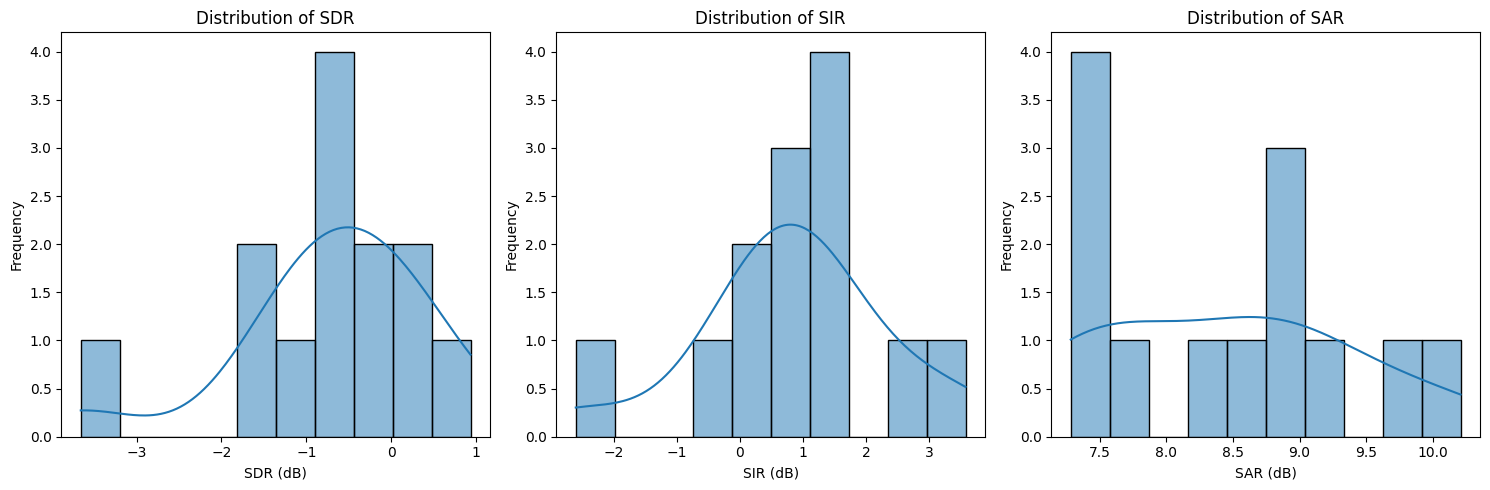

# 8.3 Statistical Summary of Metrics (Box Plot)

This cell creates a box plot to provide a statistical summary of the SDR, SIR, and SAR values. Box plots display the median, quartiles, and potential outliers for each metric, offering a concise comparison of their central tendencies and spreads.

In [ ]:
if 'df_plot' in locals():
    # 2. Box Plots
    plt.figure(figsize=(10, 6))
    sns.boxplot(data=df_plot[['sdr', 'sir', 'sar']])
    plt.xticks([0, 1, 2], ['SDR', 'SIR', 'SAR'])
    plt.title('Box Plot of Separation Metrics')
    plt.ylabel('dB')
    plt.show()

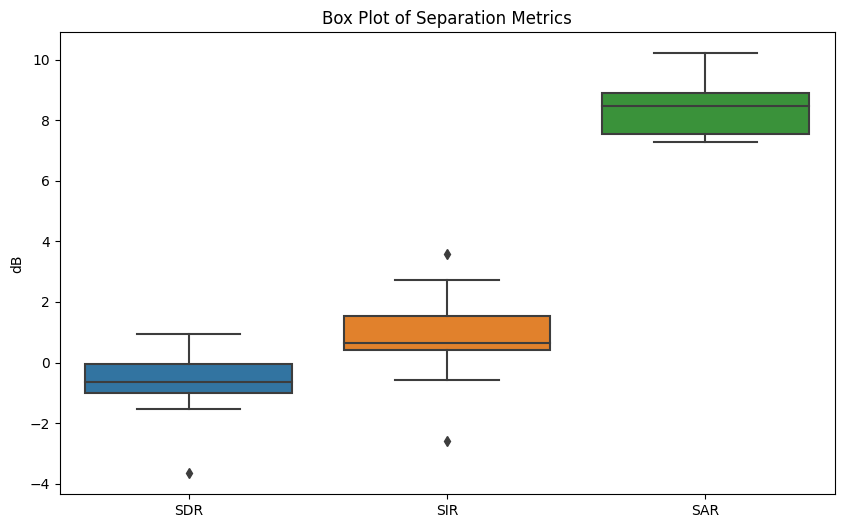

# 8.4 Distribution Shape of Metrics (Violin Plot)

This cell generates violin plots, which combine aspects of box plots and kernel density plots. Violin plots provide a richer visualization of the distribution of each metric, showing the probability density of the data at different values. This reveals more nuanced information about the shape of the performance distributions compared to box plots alone.

In [ ]:
if 'df_plot' in locals():
    # 3. Violin Plots
    plt.figure(figsize=(10, 6))
    sns.violinplot(data=df_plot[['sdr', 'sir', 'sar']])
    plt.xticks([0, 1, 2], ['SDR', 'SIR', 'SAR'])
    plt.title('Violin Plot of Separation Metrics')
    plt.ylabel('dB')
    plt.show()

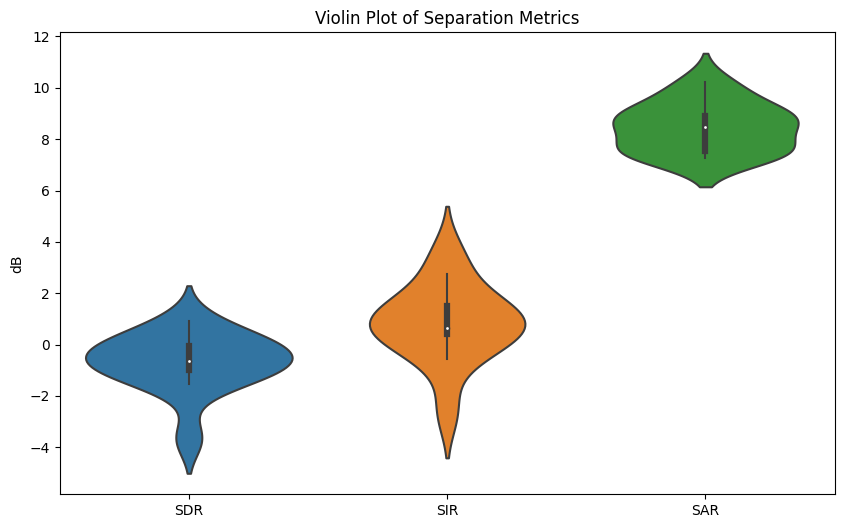

# 8.5 Performance Trends Across Songs

This cell displays the SDR, SIR, and SAR values for each individual song in the test set using a line plot. This allows us to observe the performance of the model on a per-song basis and identify any potential variations in performance across different audio samples.

In [ ]:
if 'df_plot' in locals():
    # 4. Per-Song Performance Plot
    plt.figure(figsize=(12, 6))
    plt.plot(df_plot['snt_id'], df_plot['sdr'], marker='o', label='SDR')
    plt.plot(df_plot['snt_id'], df_plot['sir'], marker='x', label='SIR')
    plt.plot(df_plot['snt_id'], df_plot['sar'], marker='s', label='SAR')
    plt.xlabel('Song ID')
    plt.ylabel('dB')
    plt.title('Separation Metrics per Song')
    plt.xticks(rotation=45, ha='right')
    plt.legend()
    plt.tight_layout()
    plt.show()

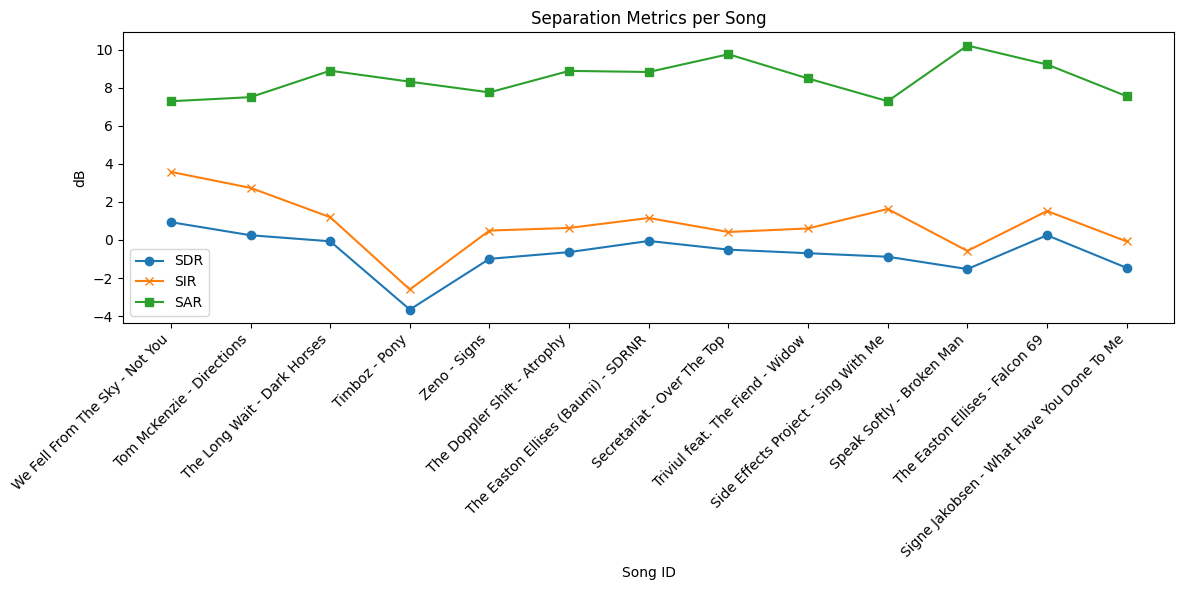

8

# 9. Conclusion

Throughout this project, several experiments were conducted to investigate the effectiveness of the developed vocal isolation model.

One key area of exploration involved comparing the model's performance when separating only two sources (vocals and drums) versus separating all four stems (vocals, drums, bass, and other). This comparison aimed to study whether a model trained on a simpler separation task (fewer sources) would achieve better performance on those specific sources compared to a model trained to separate a more complex mixture.

Furthermore, additional experiments were carried out, including the evaluation of different model architectures and training runs with varying numbers of epochs. The details and results of these experiments, along with a more in-depth analysis of the findings, are provided in the **attached report**. These experiments offer further insights into the model's capabilities and potential areas for future improvement.